<a href="https://colab.research.google.com/github/DaJeong03/voice-ai-study/blob/main/DAY2_plus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import librosa
import librosa.display
import numpy as np

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

y, sr = librosa.load(librosa.ex('trumpet'))

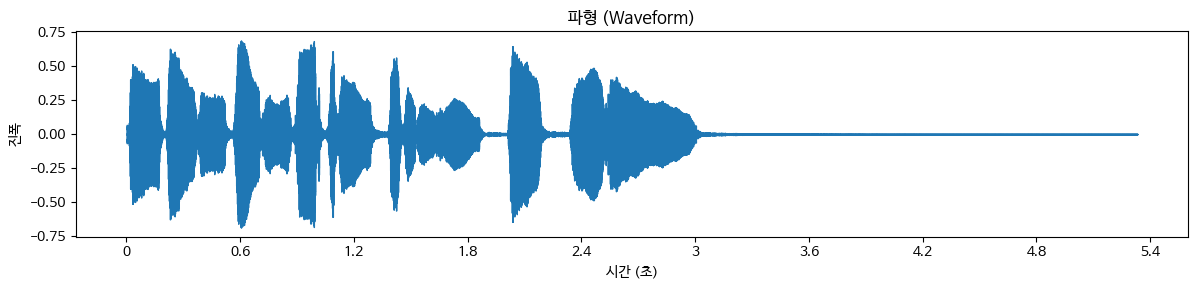

waveform.png 저장 완료!


In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set_title("파형 (Waveform)")
ax.set_xlabel("시간 (초)")
ax.set_ylabel("진폭")
plt.tight_layout()
plt.savefig("waveform.png", dpi=150, bbox_inches='tight')
plt.show()
print("waveform.png 저장 완료!")

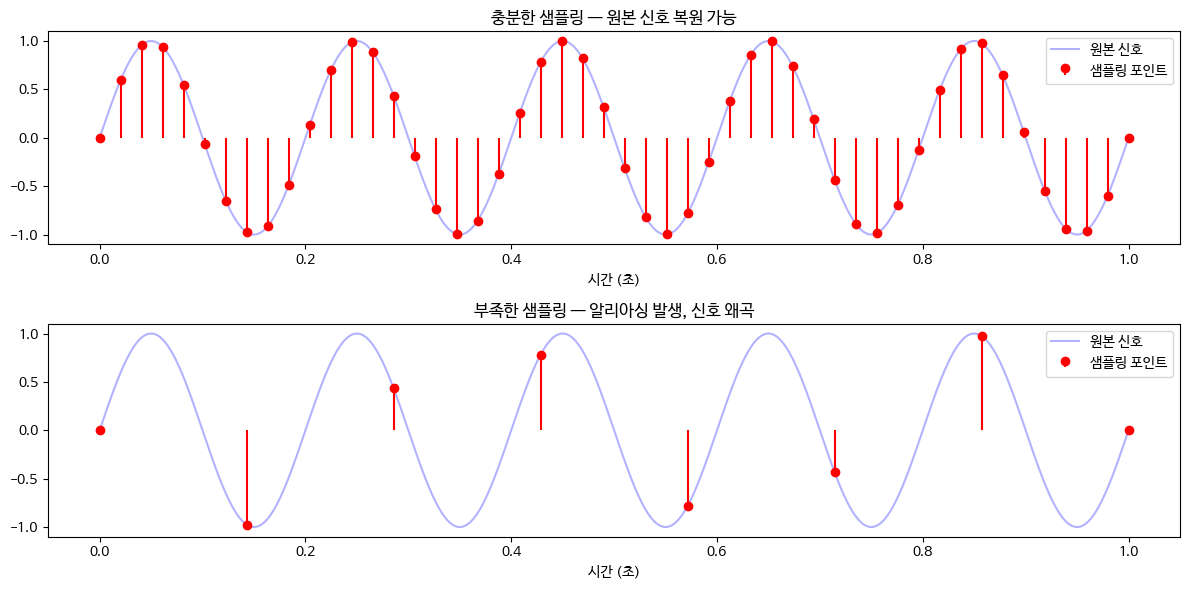

aliasing.png 저장 완료!


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 원본 신호
t = np.linspace(0, 1, 1000)
signal = np.sin(2 * np.pi * 5 * t)  # 5Hz 신호

# 충분한 샘플링 (나이퀴스트 만족)
t_good = np.linspace(0, 1, 50)
signal_good = np.sin(2 * np.pi * 5 * t_good)

# 부족한 샘플링 (나이퀴스트 불만족)
t_bad = np.linspace(0, 1, 8)
signal_bad = np.sin(2 * np.pi * 5 * t_bad)

# 위: 충분한 샘플링
axes[0].plot(t, signal, 'b-', alpha=0.3, label='원본 신호')
axes[0].stem(t_good, signal_good, 'r', markerfmt='ro',
             basefmt=' ', label='샘플링 포인트')
axes[0].set_title("충분한 샘플링 — 원본 신호 복원 가능")
axes[0].legend()
axes[0].set_xlabel("시간 (초)")

# 아래: 부족한 샘플링
axes[1].plot(t, signal, 'b-', alpha=0.3, label='원본 신호')
axes[1].stem(t_bad, signal_bad, 'r', markerfmt='ro',
             basefmt=' ', label='샘플링 포인트')
axes[1].set_title("부족한 샘플링 — 알리아싱 발생, 신호 왜곡")
axes[1].legend()
axes[1].set_xlabel("시간 (초)")

plt.tight_layout()
plt.savefig("aliasing.png", dpi=150, bbox_inches='tight')
plt.show()
print("aliasing.png 저장 완료!")

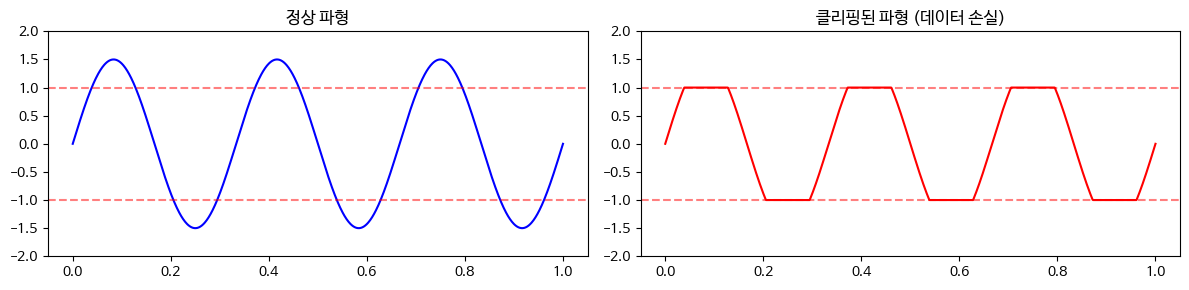

clipping.png 저장 완료!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

t = np.linspace(0, 1, 1000)
signal = np.sin(2 * np.pi * 3 * t) * 1.5

# 정상 신호
axes[0].plot(t, np.clip(signal, -1.5, 1.5), 'b-')
axes[0].set_title("정상 파형")
axes[0].set_ylim(-2, 2)
axes[0].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=-1.0, color='r', linestyle='--', alpha=0.5)

# 클리핑된 신호
axes[1].plot(t, np.clip(signal, -1.0, 1.0), 'r-')
axes[1].set_title("클리핑된 파형 (데이터 손실)")
axes[1].set_ylim(-2, 2)
axes[1].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
axes[1].axhline(y=-1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("clipping.png", dpi=150, bbox_inches='tight')
plt.show()
print("clipping.png 저장 완료!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

dest_dir = "/content/drive/MyDrive/voice-ai-study/images/"
os.makedirs(dest_dir, exist_ok=True)

shutil.copy("waveform.png", os.path.join(dest_dir, "waveform.png"))
shutil.copy("aliasing.png", os.path.join(dest_dir, "aliasing.png"))
shutil.copy("clipping.png", os.path.join(dest_dir, "clipping.png"))
print("Drive 저장 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive 저장 완료!
